In [ ]:

!git clone https://github.com/caltech-eecs148b/hw2.git
%cd hw2
!curl -LsSf https://astral.sh/uv/install.sh | sh
import os
os.environ["PATH"] = "/root/.local/bin:" + os.environ["PATH"]
!uv sync
!which nsys


Cloning into 'hw2'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 43 (delta 7), reused 41 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 435.13 KiB | 2.34 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/hw2
downloading uv 0.11.8 x86_64-unknown-linux-gnu
installing to /usr/local/bin
  uv
  uvx
everything's installed!
Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 108 packages in 1.12s
Prepared 104 packages in 25.21s
Installed 104 packages in 5.98s
 + aiohappyeyeballs==2.6.1
 + aiohttp==3.13.5
 + aiosignal==1.4.0
 + annotated-doc==0.0.4
 + annotated-types==0.7.0
 + antlr4-python3-runtime==4.13.2
 + anyio==4.13.0
 + attrs==26.1.0
 + basics==1.0.3 (from file:///content/hw2/basics)
 + certifi==2026.4.22
 + charset-normalizer==3.4.7
 + click==8.3.3
 + cloudpickle==3.1.2
 + contourpy==1.3.3
 + cycler==0.12

In [ ]:
%%bash
python - <<'PY'
from pathlib import Path

p = Path("systems/benchmark.py")
s = p.read_text()

s = s.replace(
    'parser.add_argument("--compile-model", action="store_true")\n'
    '    parser.add_argument("--output-dir", type=Path, default=Path("artifacts"))',
    'parser.add_argument("--compile-model", action="store_true")\n'
    '    parser.add_argument("--annotate-attention", action="store_true")\n'
    '    parser.add_argument("--device", choices=["auto", "cuda", "mps", "cpu"], default="auto")\n'
    '    parser.add_argument("--output-dir", type=Path, default=Path("artifacts"))'
)

s = s.replace(
    "        compile_model=args.compile_model,\n"
    "        output_dir=args.output_dir,",
    "        compile_model=args.compile_model,\n"
    "        annotate_attention=getattr(args, 'annotate_attention', False),\n"
    "        device=getattr(args, 'device', 'auto'),\n"
    "        output_dir=args.output_dir,"
)

s = s.replace(
    "    compile_model: bool = False\n"
    '    output_dir: Path = Path("artifacts")',
    "    compile_model: bool = False\n"
    "    annotate_attention: bool = False\n"
    '    device: str = "auto"\n'
    '    output_dir: Path = Path("artifacts")'
)

p.write_text(s)
PY


In [ ]:
%%writefile systems/benchmark.py
from __future__ import annotations

import argparse
import math
import statistics
import timeit
from contextlib import contextmanager, nullcontext
from dataclasses import dataclass
from pathlib import Path
from typing import Literal

import torch
import torch.nn.functional as F
from einops import einsum

try:
    import basics.model as basics_model
    from basics.nn_utils import softmax
except ModuleNotFoundError:
    import sys
    sys.path.append(str(Path(__file__).resolve().parents[1] / "basics"))
    import basics.model as basics_model
    from basics.nn_utils import softmax

BasicsTransformerLM = basics_model.BasicsTransformerLM


@dataclass(frozen=True)
class ModelSpec:
    d_model: int
    d_ff: int
    num_layers: int
    num_heads: int


MODEL_SPECS = {
    "small": ModelSpec(d_model=512, d_ff=2048, num_layers=8, num_heads=8),
    "medium": ModelSpec(d_model=768, d_ff=3072, num_layers=12, num_heads=12),
    "large": ModelSpec(d_model=1024, d_ff=4096, num_layers=24, num_heads=16),
}


@dataclass(frozen=True)
class BenchmarkConfig:
    model_size: str
    context_length: int = 128
    batch_size: int = 4
    vocab_size: int = 10_000
    warmup_steps: int = 5
    measure_steps: int = 10
    mode: Literal["forward", "forward-backward", "train-step"] = "forward"
    use_bf16: bool = False
    compile_model: bool = False
    annotate_attention: bool = False
    device: str = "auto"
    output_dir: Path = Path("artifacts")


def build_argparser():
    parser = argparse.ArgumentParser()
    parser.add_argument("--model-size", choices=sorted(MODEL_SPECS), required=True)
    parser.add_argument("--context-length", type=int, default=128)
    parser.add_argument("--batch-size", type=int, default=4)
    parser.add_argument("--vocab-size", type=int, default=10_000)
    parser.add_argument("--warmup-steps", type=int, default=5)
    parser.add_argument("--measure-steps", type=int, default=10)
    parser.add_argument("--mode", choices=["forward", "forward-backward", "train-step"], default="forward")
    parser.add_argument("--use-bf16", action="store_true")
    parser.add_argument("--compile-model", action="store_true")
    parser.add_argument("--annotate-attention", action="store_true")
    parser.add_argument("--device", choices=["auto", "cuda", "mps", "cpu"], default="auto")
    parser.add_argument("--output-dir", type=Path, default=Path("artifacts"))
    return parser


def get_device(requested_device: str):
    if requested_device == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")
    return torch.device(requested_device)


def synchronize_device(device):
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps" and hasattr(torch, "mps"):
        torch.mps.synchronize()


@contextmanager
def nvtx_range(message: str):
    if torch.cuda.is_available():
        torch.cuda.nvtx.range_push(message)
        try:
            yield
        finally:
            torch.cuda.nvtx.range_pop()
    else:
        yield


def build_model(config):
    spec = MODEL_SPECS[config.model_size]
    return BasicsTransformerLM(
        vocab_size=config.vocab_size,
        context_length=config.context_length,
        d_model=spec.d_model,
        num_layers=spec.num_layers,
        num_heads=spec.num_heads,
        d_ff=spec.d_ff,
        rope_theta=10_000.0,
    )


def make_random_batch(config, device):
    return torch.randint(
        0,
        config.vocab_size,
        (config.batch_size, config.context_length),
        device=device,
        dtype=torch.long,
    )


def make_autocast_context(use_bf16, device):
    if use_bf16:
        return torch.autocast(device_type=device.type, dtype=torch.bfloat16)
    return nullcontext()


def run_single_step(model, batch, mode, autocast_context, optimizer=None):
    device = batch.device
    timings = {}

    if mode == "forward":
        start = timeit.default_timer()
        with torch.no_grad(), autocast_context, nvtx_range("forward"):
            model(batch)
        synchronize_device(device)
        timings["forward_s"] = timeit.default_timer() - start
        timings["step_s"] = timings["forward_s"]
        return timings

    model.zero_grad(set_to_none=True)
    if optimizer is not None:
        optimizer.zero_grad(set_to_none=True)

    start = timeit.default_timer()
    with autocast_context, nvtx_range("forward"):
        logits = model(batch)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), batch.reshape(-1))
    synchronize_device(device)
    timings["forward_s"] = timeit.default_timer() - start

    start = timeit.default_timer()
    with nvtx_range("backward"):
        loss.backward()
    synchronize_device(device)
    timings["backward_s"] = timeit.default_timer() - start

    if mode == "train-step":
        start = timeit.default_timer()
        with nvtx_range("optimizer_step"):
            optimizer.step()
        synchronize_device(device)
        timings["optimizer_s"] = timeit.default_timer() - start

    timings["step_s"] = timings["forward_s"] + timings.get("backward_s", 0.0) + timings.get("optimizer_s", 0.0)
    return timings


def benchmark_model(config):
    torch.manual_seed(0)
    device = get_device(config.device)

    if config.annotate_attention:
        basics_model.scaled_dot_product_attention = annotated_scaled_dot_product_attention

    model = build_model(config).to(device)
    model.train(config.mode != "forward")

    if config.compile_model:
        model = torch.compile(model)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3) if config.mode == "train-step" else None
    batch = make_random_batch(config, device)
    autocast_context = make_autocast_context(config.use_bf16, device)

    for step in range(config.warmup_steps):
        with nvtx_range(f"warmup_step_{step}"):
            run_single_step(model, batch, config.mode, autocast_context, optimizer)

    measurements = {}
    for step in range(config.measure_steps):
        with nvtx_range(f"measure_step_{step}"):
            step_timings = run_single_step(model, batch, config.mode, autocast_context, optimizer)
        for key, value in step_timings.items():
            measurements.setdefault(key, []).append(value)

    results = {"params": float(sum(p.numel() for p in model.parameters()))}
    for key, values in measurements.items():
        results[f"{key}_mean"] = statistics.mean(values)
        results[f"{key}_std"] = statistics.stdev(values) if len(values) > 1 else 0.0

    print(", ".join(
        f"{k}={v:.6f}" if isinstance(v, float) else f"{k}={v}"
        for k, v in {
            "model_size": config.model_size,
            "mode": config.mode,
            "device": device.type,
            "context_length": config.context_length,
            "warmup_steps": config.warmup_steps,
            "measure_steps": config.measure_steps,
            **results,
        }.items()
    ))
    return results


def annotated_scaled_dot_product_attention(*args, **kwargs):
    Q = kwargs.get("Q", args[0] if len(args) > 0 else None)
    K = kwargs.get("K", args[1] if len(args) > 1 else None)
    V = kwargs.get("V", args[2] if len(args) > 2 else None)
    mask = kwargs.get("mask", args[3] if len(args) > 3 else None)

    with nvtx_range("scaled_dot_product_attention"):
        d_k = K.shape[-1]
        with nvtx_range("attention_scores"):
            attention_scores = einsum(Q, K, "... query d_k, ... key d_k -> ... query key") / math.sqrt(d_k)

        if mask is not None:
            with nvtx_range("attention_mask"):
                attention_scores = torch.where(mask, attention_scores, float("-inf"))

        with nvtx_range("attention_softmax"):
            attention_weights = softmax(attention_scores, dim=-1)

        with nvtx_range("attention_values_matmul"):
            return einsum(attention_weights, V, "... query key, ... key d_v -> ... query d_v")


def main():
    args = build_argparser().parse_args()
    config = BenchmarkConfig(**vars(args))
    benchmark_model(config)


if __name__ == "__main__":
    main()


Overwriting systems/benchmark.py


In [ ]:
%%bash
export PATH="/root/.local/bin:$PATH"
uv run python systems/benchmark.py \
  --model-size small \
  --context-length 128 \
  --mode forward-backward \
  --warmup-steps 5 \
  --measure-steps 10 \
  --device cuda


model_size=small, mode=forward-backward, device=cuda, context_length=128, warmup_steps=5, measure_steps=10, params=43803136.000000, forward_s_mean=0.013337, forward_s_std=0.000598, backward_s_mean=0.013034, backward_s_std=0.000705, step_s_mean=0.026371, step_s_std=0.001074


In [ ]:
%%bash

export PATH="/root/.local/bin:$PATH"
mkdir -p profiles

for size in small medium large; do
  for ctx in 32 64 128 256; do
    echo "Profiling size=$size ctx=$ctx"
    nsys profile \
      --force-overwrite=true \
      --stats=true \
      --trace=cuda,nvtx,osrt,cublas,cudnn \
      --capture-range=none \
      -o "profiles/${size}_ctx${ctx}_train_step" \
      uv run python systems/benchmark.py \
        --model-size "$size" \
        --context-length "$ctx" \
        --mode train-step \
        --warmup-steps 5 \
        --measure-steps 1 \
        --device cuda \
        --annotate-attention || true
  done
done


Profiling size=small ctx=32
Profiling size=small ctx=64
Profiling size=small ctx=128
Profiling size=small ctx=256
Profiling size=medium ctx=32
Profiling size=medium ctx=64
Profiling size=medium ctx=128
Profiling size=medium ctx=256
Profiling size=large ctx=32
Profiling size=large ctx=64
Profiling size=large ctx=128
Profiling size=large ctx=256


bash: line 8: nsys: command not found
bash: line 8: nsys: command not found
bash: line 8: nsys: command not found
bash: line 8: nsys: command not found
bash: line 8: nsys: command not found
bash: line 8: nsys: command not found
bash: line 8: nsys: command not found
bash: line 8: nsys: command not found
bash: line 8: nsys: command not found
bash: line 8: nsys: command not found
bash: line 8: nsys: command not found
bash: line 8: nsys: command not found


In [ ]:
%%bash

for report in profiles/*.nsys-rep; do
  echo "===== $report ====="
  nsys stats --report nvtx_sum,cuda_gpu_kern_sum,cuda_api_sum "$report" || true
done


===== profiles/*.nsys-rep =====


bash: line 4: nsys: command not found


In [ ]:

!zip -r hw2_2_4_nsys_profiles.zip profiles
from google.colab import files
files.download("hw2_2_4_nsys_profiles.zip")


  adding: profiles/ (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%bash
find profiles -maxdepth 2 -type f -print -exec ls -lh {} \;


In [ ]:
%%bash
set -euo pipefail

DISTRO="ubuntu$(. /etc/os-release; echo "$VERSION_ID" | tr -d .)"
ARCH="$(dpkg --print-architecture)"

apt-get update -qq
apt-get install -y -qq wget gnupg ca-certificates

wget -qO- "https://developer.download.nvidia.com/devtools/repos/${DISTRO}/${ARCH}/nvidia.pub" \
  | gpg --dearmor > /usr/share/keyrings/nvidia-devtools.gpg

echo "deb [signed-by=/usr/share/keyrings/nvidia-devtools.gpg] https://developer.download.nvidia.com/devtools/repos/${DISTRO}/${ARCH}/ /" \
  > /etc/apt/sources.list.d/nvidia-devtools.list

apt-get update -qq
apt-get install -y -qq nsight-systems-cli

which nsys
nsys --version


Selecting previously unselected package nsight-systems-cli-2026.2.1.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../nsight-systems-cli-2026.2.1_2026.2.1.210-262137639646v0_amd64.deb ...
Unpacking nsight-systems-cli-2026.2.1 (2026.2.1.210-262137639646v0) ...
Selecting previously unselected package nsight-systems-cli.
Preparing to unpack .../nsight-systems-cli_2026.2.1.210_amd64.deb ...
Unpacking nsight-systems-cli (2026.2.1.210) ...
Setting up nsight-systems-cli-2026.2.1 (2026.2.1.210-262137639646v0) ...
update-alternatives: using /opt/nvidia/nsight-systems-cli/2026.2.1/target-linux-x64/nsys to provide /usr/local/bin/nsys (nsys) in auto mode
Setting up nsight-systems-cli (2026.2.1.210) ...
/usr/local/bin/nsys
NVIDIA Nsight Systems version 2026.2.1.210-262137639646v0


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
%%bash
set -euo pipefail
export PATH="/root/.local/bin:$PATH"
mkdir -p profiles stats

for size in small medium large; do
  for ctx in 32 64 128 256; do
    echo "Profiling size=$size ctx=$ctx"
    nsys profile \
      --force-overwrite=true \
      --stats=true \
      --trace=cuda,nvtx,osrt,cublas,cudnn \
      -o "profiles/${size}_ctx${ctx}_train_step" \
      uv run python systems/benchmark.py \
        --model-size "$size" \
        --context-length "$ctx" \
        --mode train-step \
        --warmup-steps 5 \
        --measure-steps 1 \
        --device cuda \
        --annotate-attention

    nsys stats \
      --report nvtx_sum,cuda_gpu_kern_sum,cuda_api_sum \
      "profiles/${size}_ctx${ctx}_train_step.nsys-rep" \
      > "stats/${size}_ctx${ctx}_stats.txt"
  done
done

find profiles stats -type f -ls
zip -r hw2_2_4_nsys_profiles_and_stats.zip profiles stats


Profiling size=small ctx=32
model_size=small, mode=train-step, device=cuda, context_length=32, warmup_steps=5, measure_steps=1, params=43803136.000000, forward_s_mean=0.019297, forward_s_std=0.000000, backward_s_mean=0.021509, backward_s_std=0.000000, optimizer_s_mean=0.002068, optimizer_s_std=0.000000, step_s_mean=0.042874, step_s_std=0.000000
Generating '/tmp/nsys-root/nsys-report-c43a.qdstrm'
[1/8] [========================100%] small_ctx32_train_step.nsys-rep
[2/8] [========================100%] small_ctx32_train_step.sqlite
[3/8] Executing 'nvtx_sum' stats report

 Time (%)  Total Time (ns)  Instances    Avg (ns)       Med (ns)      Min (ns)     Max (ns)     StdDev (ns)    Style                    Range                  
 --------  ---------------  ---------  -------------  -------------  -----------  -----------  -------------  -------  ----------------------------------------
     34.0      754,621,679          1  754,621,679.0  754,621,679.0  754,621,679  754,621,679           


         File is older than input file: profiles/small_ctx32_train_step.nsys-rep
         Use --force-export=true to update export file.

usage: nsys stats [<args>] <input-file>
Try 'nsys stats --help' for more information.


CalledProcessError: Command 'b'set -euo pipefail\nexport PATH="/root/.local/bin:$PATH"\nmkdir -p profiles stats\n\nfor size in small medium large; do\n  for ctx in 32 64 128 256; do\n    echo "Profiling size=$size ctx=$ctx"\n    nsys profile \\\n      --force-overwrite=true \\\n      --stats=true \\\n      --trace=cuda,nvtx,osrt,cublas,cudnn \\\n      -o "profiles/${size}_ctx${ctx}_train_step" \\\n      uv run python systems/benchmark.py \\\n        --model-size "$size" \\\n        --context-length "$ctx" \\\n        --mode train-step \\\n        --warmup-steps 5 \\\n        --measure-steps 1 \\\n        --device cuda \\\n        --annotate-attention\n\n    nsys stats \\\n      --report nvtx_sum,cuda_gpu_kern_sum,cuda_api_sum \\\n      "profiles/${size}_ctx${ctx}_train_step.nsys-rep" \\\n      > "stats/${size}_ctx${ctx}_stats.txt"\n  done\ndone\n\nfind profiles stats -type f -ls\nzip -r hw2_2_4_nsys_profiles_and_stats.zip profiles stats\n'' returned non-zero exit status 1.

In [ ]:
%%bash
set -euo pipefail
export PATH="/root/.local/bin:$PATH"

rm -rf profiles stats
mkdir -p profiles stats

for size in small medium large; do
  for ctx in 32 64 128 256; do
    echo "Profiling size=$size ctx=$ctx"
    nsys profile \
      --force-overwrite=true \
      --stats=true \
      --trace=cuda,nvtx,osrt,cublas,cudnn \
      -o "profiles/${size}_ctx${ctx}_train_step" \
      uv run python systems/benchmark.py \
        --model-size "$size" \
        --context-length "$ctx" \
        --mode train-step \
        --warmup-steps 5 \
        --measure-steps 1 \
        --device cuda \
        --annotate-attention \
      2>&1 | tee "stats/${size}_ctx${ctx}_stats.txt"
  done
done

find profiles stats -type f -ls
zip -r hw2_2_4_nsys_profiles_and_stats.zip profiles stats


Profiling size=small ctx=32
model_size=small, mode=train-step, device=cuda, context_length=32, warmup_steps=5, measure_steps=1, params=43803136.000000, forward_s_mean=0.017675, forward_s_std=0.000000, backward_s_mean=0.020808, backward_s_std=0.000000, optimizer_s_mean=0.002023, optimizer_s_std=0.000000, step_s_mean=0.040507, step_s_std=0.000000
Generating '/tmp/nsys-root/nsys-report-973d.qdstrm'
[1/8] [========================100%] small_ctx32_train_step.nsys-rep
[2/8] [========================100%] small_ctx32_train_step.sqlite
[3/8] Executing 'nvtx_sum' stats report

 Time (%)  Total Time (ns)  Instances    Avg (ns)       Med (ns)      Min (ns)     Max (ns)     StdDev (ns)    Style                    Range                  
 --------  ---------------  ---------  -------------  -------------  -----------  -----------  -------------  -------  ----------------------------------------
     34.1      705,677,161          1  705,677,161.0  705,677,161.0  705,677,161  705,677,161           

In [ ]:
from google.colab import files
files.download("hw2_2_4_nsys_profiles_and_stats.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%bash
set -euo pipefail
export PATH="/root/.local/bin:$PATH"

mkdir -p artifacts_2_5

nvidia-smi | tee artifacts_2_5/gpu_info.txt

cat > artifacts_2_5/toy_autocast_dtype.py <<'PY'
import torch
import torch.nn as nn
import torch.nn.functional as F

class ToyModel(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 10, bias=False)
        self.ln = nn.LayerNorm(10)
        self.fc2 = nn.Linear(10, out_features, bias=False)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.ln(x)
        x = self.fc2(x)
        return x

device = "cuda"
model = ToyModel(16, 4).to(device)
x = torch.randn(8, 16, device=device)
target = torch.randint(0, 4, (8,), device=device)

print("parameter dtypes before autocast:", sorted({p.dtype for p in model.parameters()}))

with torch.autocast(device_type="cuda", dtype=torch.float16):
    fc1_out = model.fc1(x)
    relu_out = model.relu(fc1_out)
    ln_out = model.ln(relu_out)
    logits = model.fc2(ln_out)
    loss = F.cross_entropy(logits, target)

print("parameter dtypes inside/autocast unchanged:", sorted({p.dtype for p in model.parameters()}))
print("fc1 output dtype:", fc1_out.dtype)
print("layer norm output dtype:", ln_out.dtype)
print("logits dtype:", logits.dtype)
print("loss dtype:", loss.dtype)

loss.backward()
print("gradient dtypes:", sorted({p.grad.dtype for p in model.parameters() if p.grad is not None}))
PY

uv run python artifacts_2_5/toy_autocast_dtype.py | tee artifacts_2_5/toy_autocast_dtype.txt


Wed Apr 29 05:15:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   35C    P0             71W /  700W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
%%bash
set -euo pipefail
export PATH="/root/.local/bin:$PATH"

: > artifacts_2_5/benchmark_2_5.txt

for size in small medium large; do
  echo "===== ${size} fp32 =====" | tee -a artifacts_2_5/benchmark_2_5.txt
  uv run python systems/benchmark.py \
    --model-size "$size" \
    --context-length 128 \
    --mode forward-backward \
    --warmup-steps 5 \
    --measure-steps 10 \
    --device cuda \
    | tee -a artifacts_2_5/benchmark_2_5.txt

  echo "===== ${size} bf16 autocast =====" | tee -a artifacts_2_5/benchmark_2_5.txt
  uv run python systems/benchmark.py \
    --model-size "$size" \
    --context-length 128 \
    --mode forward-backward \
    --warmup-steps 5 \
    --measure-steps 10 \
    --device cuda \
    --use-bf16 \
    | tee -a artifacts_2_5/benchmark_2_5.txt
done

zip -r hw2_2_5_results.zip artifacts_2_5


===== small fp32 =====
model_size=small, mode=forward-backward, device=cuda, context_length=128, warmup_steps=5, measure_steps=10, params=43803136.000000, forward_s_mean=0.014083, forward_s_std=0.000498, backward_s_mean=0.014710, backward_s_std=0.000531, step_s_mean=0.028793, step_s_std=0.000951
===== small bf16 autocast =====
model_size=small, mode=forward-backward, device=cuda, context_length=128, warmup_steps=5, measure_steps=10, params=43803136.000000, forward_s_mean=0.014309, forward_s_std=0.000607, backward_s_mean=0.014839, backward_s_std=0.000761, step_s_mean=0.029147, step_s_std=0.001205
===== medium fp32 =====
model_size=medium, mode=forward-backward, device=cuda, context_length=128, warmup_steps=5, measure_steps=10, params=128625408.000000, forward_s_mean=0.019383, forward_s_std=0.000619, backward_s_mean=0.019588, backward_s_std=0.000676, step_s_mean=0.038972, step_s_std=0.001030
===== medium bf16 autocast =====
model_size=medium, mode=forward-backward, device=cuda, context_l

In [ ]:
from google.colab import files
files.download("hw2_2_5_results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%bash
set -euo pipefail
export PATH="/root/.local/bin:$PATH"

mkdir -p artifacts_2_6

cat > artifacts_2_6/run_memory_2_6.py <<'PY'
import gc
import math
import statistics
import timeit
from contextlib import nullcontext
from dataclasses import dataclass
from pathlib import Path

import torch
import torch.nn.functional as F

try:
    from basics.model import BasicsTransformerLM
except ModuleNotFoundError:
    import sys
    sys.path.append("basics")
    from basics.model import BasicsTransformerLM


@dataclass(frozen=True)
class Spec:
    d_model: int = 1024
    d_ff: int = 4096
    num_layers: int = 24
    num_heads: int = 16


def build_model(ctx, vocab_size=10_000):
    s = Spec()
    return BasicsTransformerLM(
        vocab_size=vocab_size,
        context_length=ctx,
        d_model=s.d_model,
        num_layers=s.num_layers,
        num_heads=s.num_heads,
        d_ff=s.d_ff,
        rope_theta=10_000.0,
    )


def sync():
    torch.cuda.synchronize()


def run_once(model, batch, mode, use_bf16, optimizer=None):
    autocast = torch.autocast(device_type="cuda", dtype=torch.bfloat16) if use_bf16 else nullcontext()

    if mode == "forward":
        with torch.no_grad(), autocast:
            model(batch)
        sync()
        return

    model.zero_grad(set_to_none=True)
    optimizer.zero_grad(set_to_none=True)
    with autocast:
        logits = model(batch)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), batch.reshape(-1))
    sync()
    loss.backward()
    sync()
    optimizer.step()
    sync()


def profile(ctx, mode, use_bf16, outdir):
    device = torch.device("cuda")
    vocab_size = 10_000
    batch_size = 4

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    model = build_model(ctx, vocab_size).to(device)
    model.train(mode != "forward")
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3) if mode == "train-step" else None
    batch = torch.randint(0, vocab_size, (batch_size, ctx), device=device)

    for _ in range(5):
        run_once(model, batch, mode, use_bf16, optimizer)

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.memory._record_memory_history(max_entries=1_000_000)

    start = timeit.default_timer()
    run_once(model, batch, mode, use_bf16, optimizer)
    elapsed = timeit.default_timer() - start

    peak_alloc = torch.cuda.max_memory_allocated() / 1024**2
    peak_reserved = torch.cuda.max_memory_reserved() / 1024**2

    tag = f"large_ctx{ctx}_{mode}_{'bf16' if use_bf16 else 'fp32'}"
    snapshot_path = outdir / f"{tag}.pickle"
    torch.cuda.memory._dump_snapshot(str(snapshot_path))
    torch.cuda.memory._record_memory_history(enabled=None)

    print(
        f"ctx={ctx}, mode={mode}, dtype={'bf16' if use_bf16 else 'fp32'}, "
        f"elapsed_s={elapsed:.6f}, peak_allocated_mib={peak_alloc:.3f}, "
        f"peak_reserved_mib={peak_reserved:.3f}, snapshot={snapshot_path}"
    )

    del model, optimizer, batch
    gc.collect()
    torch.cuda.empty_cache()


def main():
    outdir = Path("artifacts_2_6/memory_snapshots")
    outdir.mkdir(parents=True, exist_ok=True)

    # 2.6(1)-(2): large model, forward vs full train step, FP32, all context lengths.
    for ctx in [32, 64, 128, 256]:
        profile(ctx, "forward", False, outdir)
        profile(ctx, "train-step", False, outdir)

    # 2.6(3): reference ctx=128 mixed precision, forward and train step.
    profile(128, "forward", True, outdir)
    profile(128, "train-step", True, outdir)


if __name__ == "__main__":
    main()
PY

uv run python artifacts_2_6/run_memory_2_6.py | tee artifacts_2_6/memory_2_6_results.txt
zip -r hw2_2_6_results.zip artifacts_2_6


ctx=32, mode=forward, dtype=fp32, elapsed_s=0.045866, peak_allocated_mib=1656.200, peak_reserved_mib=1674.000, snapshot=artifacts_2_6/memory_snapshots/large_ctx32_forward_fp32.pickle
ctx=32, mode=train-step, dtype=fp32, elapsed_s=0.126173, peak_allocated_mib=8149.849, peak_reserved_mib=8338.000, snapshot=artifacts_2_6/memory_snapshots/large_ctx32_train-step_fp32.pickle
ctx=64, mode=forward, dtype=fp32, elapsed_s=0.044642, peak_allocated_mib=1696.209, peak_reserved_mib=1710.000, snapshot=artifacts_2_6/memory_snapshots/large_ctx64_forward_fp32.pickle
ctx=64, mode=train-step, dtype=fp32, elapsed_s=0.125880, peak_allocated_mib=8154.741, peak_reserved_mib=8460.000, snapshot=artifacts_2_6/memory_snapshots/large_ctx64_train-step_fp32.pickle
ctx=128, mode=forward, dtype=fp32, elapsed_s=0.045086, peak_allocated_mib=1712.227, peak_reserved_mib=1746.000, snapshot=artifacts_2_6/memory_snapshots/large_ctx128_forward_fp32.pickle
ctx=128, mode=train-step, dtype=fp32, elapsed_s=0.108677, peak_allocate

In [ ]:
from google.colab import files
files.download("hw2_2_6_results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%writefile systems/attention_benchmark.py
from __future__ import annotations

import argparse
import csv
import gc
import statistics
import timeit
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import torch

try:
    from basics.model import scaled_dot_product_attention
except ModuleNotFoundError:
    import sys
    sys.path.append(str(Path(__file__).resolve().parents[1] / "basics"))
    from basics.model import scaled_dot_product_attention


@dataclass(frozen=True)
class AttentionBenchmarkConfig:
    head_dims: tuple[int, ...] = (16, 32, 64, 128)
    sequence_lengths: tuple[int, ...] = (64, 128, 256, 512, 1024)
    batch_size: int = 8
    forward_passes: int = 100
    backward_passes: int = 100
    warmup_steps: int = 10
    compile_attention: bool = False
    device: str = "auto"
    output_csv: Path | None = None


def build_argparser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(description="Benchmark attention implementations.")
    parser.add_argument("--compile-attention", action="store_true")
    parser.add_argument("--device", choices=["auto", "cuda", "mps", "cpu"], default="auto")
    parser.add_argument("--forward-passes", type=int, default=100)
    parser.add_argument("--backward-passes", type=int, default=100)
    parser.add_argument("--warmup-steps", type=int, default=10)
    parser.add_argument("--output-csv", type=Path)
    return parser


def iter_benchmark_shapes(config: AttentionBenchmarkConfig) -> Iterable[tuple[int, int]]:
    for head_dim in config.head_dims:
        for sequence_length in config.sequence_lengths:
            yield head_dim, sequence_length


def get_device(requested_device: str) -> torch.device:
    if requested_device == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")
    device = torch.device(requested_device)
    if device.type == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA requested but unavailable")
    return device


def synchronize_device(device: torch.device) -> None:
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps" and hasattr(torch, "mps"):
        torch.mps.synchronize()


def make_qkv(batch_size: int, sequence_length: int, head_dim: int, device: torch.device) -> tuple[torch.Tensor, ...]:
    q = torch.randn(batch_size, sequence_length, head_dim, device=device, requires_grad=True)
    k = torch.randn(batch_size, sequence_length, head_dim, device=device, requires_grad=True)
    v = torch.randn(batch_size, sequence_length, head_dim, device=device, requires_grad=True)
    return q, k, v


def make_causal_mask(sequence_length: int, device: torch.device) -> torch.Tensor:
    positions = torch.arange(sequence_length, device=device)
    return positions[:, None] >= positions[None, :]


def make_attention_fn(compile_attention: bool):
    def attention_fn(q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        return scaled_dot_product_attention(Q=q, K=k, V=v, mask=mask)

    return torch.compile(attention_fn) if compile_attention else attention_fn


def benchmark_attention_once(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    *,
    attention_fn,
    mask: torch.Tensor,
    forward_passes: int,
    backward_passes: int,
    warmup_steps: int,
) -> dict[str, float]:
    device = q.device

    for _ in range(warmup_steps):
        out = attention_fn(q, k, v, mask)
        loss = out.square().mean()
        loss.backward()
        q.grad = k.grad = v.grad = None
        synchronize_device(device)

    forward_times = []
    for _ in range(forward_passes):
        q.grad = k.grad = v.grad = None
        start = timeit.default_timer()
        out = attention_fn(q, k, v, mask)
        synchronize_device(device)
        forward_times.append(timeit.default_timer() - start)
        del out

    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

    backward_times = []
    memory_before_backward_mib = 0.0
    for i in range(backward_passes):
        q.grad = k.grad = v.grad = None
        out = attention_fn(q, k, v, mask)
        loss = out.square().mean()
        synchronize_device(device)

        if device.type == "cuda" and i == 0:
            memory_before_backward_mib = torch.cuda.memory_allocated(device) / 1024**2

        start = timeit.default_timer()
        loss.backward()
        synchronize_device(device)
        backward_times.append(timeit.default_timer() - start)

        del out, loss

    result = {
        "forward_mean_ms": statistics.mean(forward_times) * 1000,
        "forward_std_ms": statistics.stdev(forward_times) * 1000 if len(forward_times) > 1 else 0.0,
        "backward_mean_ms": statistics.mean(backward_times) * 1000,
        "backward_std_ms": statistics.stdev(backward_times) * 1000 if len(backward_times) > 1 else 0.0,
        "memory_before_backward_mib": memory_before_backward_mib,
    }
    if device.type == "cuda":
        result["peak_allocated_mib"] = torch.cuda.max_memory_allocated(device) / 1024**2
        result["peak_reserved_mib"] = torch.cuda.max_memory_reserved(device) / 1024**2
    return result


def print_row(row: dict[str, float | int | str]) -> None:
    print(", ".join(
        f"{key}={value:.3f}" if isinstance(value, float) else f"{key}={value}"
        for key, value in row.items()
    ))


def benchmark_attention_grid(config: AttentionBenchmarkConfig) -> list[dict[str, float | int | str]]:
    device = get_device(config.device)
    attention_fn = make_attention_fn(config.compile_attention)
    rows = []

    for head_dim, sequence_length in iter_benchmark_shapes(config):
        row = {
            "batch_size": config.batch_size,
            "sequence_length": sequence_length,
            "head_dim": head_dim,
            "compiled": str(config.compile_attention),
            "device": device.type,
        }
        q = k = v = mask = None
        try:
            q, k, v = make_qkv(config.batch_size, sequence_length, head_dim, device)
            mask = make_causal_mask(sequence_length, device)
            row.update(benchmark_attention_once(
                q, k, v,
                attention_fn=attention_fn,
                mask=mask,
                forward_passes=config.forward_passes,
                backward_passes=config.backward_passes,
                warmup_steps=config.warmup_steps,
            ))
            row["status"] = "ok"
        except torch.cuda.OutOfMemoryError as exc:
            row["status"] = "oom"
            row["error"] = str(exc).splitlines()[0]
            torch.cuda.empty_cache()
        finally:
            rows.append(row)
            print_row(row)
            del q, k, v, mask
            gc.collect()
            if device.type == "cuda":
                torch.cuda.empty_cache()

    if config.output_csv is not None:
        config.output_csv.parent.mkdir(parents=True, exist_ok=True)
        fieldnames = sorted({key for row in rows for key in row})
        with config.output_csv.open("w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(rows)

    return rows


def main() -> None:
    args = build_argparser().parse_args()
    config = AttentionBenchmarkConfig(
        forward_passes=args.forward_passes,
        backward_passes=args.backward_passes,
        warmup_steps=args.warmup_steps,
        compile_attention=args.compile_attention,
        device=args.device,
        output_csv=args.output_csv,
    )
    benchmark_attention_grid(config)


if __name__ == "__main__":
    main()


Overwriting systems/attention_benchmark.py


In [ ]:
%%bash
set -euo pipefail
export PATH="/root/.local/bin:$PATH"

mkdir -p artifacts_2_7

uv run python systems/attention_benchmark.py \
  --device cuda \
  --forward-passes 100 \
  --backward-passes 100 \
  --warmup-steps 10 \
  --output-csv artifacts_2_7/attention_2_7.csv \
  | tee artifacts_2_7/attention_2_7.txt

nvidia-smi > artifacts_2_7/gpu_info.txt
zip -r hw2_2_7_results.zip artifacts_2_7


batch_size=8, sequence_length=64, head_dim=16, compiled=False, device=cuda, forward_mean_ms=0.168, forward_std_ms=0.016, backward_mean_ms=0.459, backward_std_ms=0.051, memory_before_backward_mib=64.385, peak_allocated_mib=64.917, peak_reserved_mib=66.000, status=ok
batch_size=8, sequence_length=128, head_dim=16, compiled=False, device=cuda, forward_mean_ms=0.161, forward_std_ms=0.023, backward_mean_ms=0.466, backward_std_ms=0.053, memory_before_backward_mib=65.278, peak_allocated_mib=67.341, peak_reserved_mib=68.000, status=ok
batch_size=8, sequence_length=256, head_dim=16, compiled=False, device=cuda, forward_mean_ms=0.151, forward_std_ms=0.019, backward_mean_ms=0.457, backward_std_ms=0.030, memory_before_backward_mib=68.586, peak_allocated_mib=76.712, peak_reserved_mib=86.000, status=ok
batch_size=8, sequence_length=512, head_dim=16, compiled=False, device=cuda, forward_mean_ms=0.174, forward_std_ms=0.016, backward_mean_ms=0.463, backward_std_ms=0.073, memory_before_backward_mib=81.2

In [ ]:
from google.colab import files
files.download("hw2_2_7_results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%bash
set -euo pipefail
export PATH="/root/.local/bin:$PATH"

mkdir -p artifacts_2_8

nvidia-smi > artifacts_2_8/gpu_info.txt

echo "=== Attention: uncompiled ===" | tee artifacts_2_8/attention_compile_2_8.txt
uv run python systems/attention_benchmark.py \
  --device cuda \
  --forward-passes 100 \
  --backward-passes 100 \
  --warmup-steps 10 \
  --output-csv artifacts_2_8/attention_uncompiled_2_8.csv \
  | tee -a artifacts_2_8/attention_compile_2_8.txt

echo "=== Attention: compiled ===" | tee -a artifacts_2_8/attention_compile_2_8.txt
uv run python systems/attention_benchmark.py \
  --device cuda \
  --compile-attention \
  --forward-passes 100 \
  --backward-passes 100 \
  --warmup-steps 10 \
  --output-csv artifacts_2_8/attention_compiled_2_8.csv \
  | tee -a artifacts_2_8/attention_compile_2_8.txt


=== Attention: uncompiled ===
batch_size=8, sequence_length=64, head_dim=16, compiled=False, device=cuda, forward_mean_ms=0.158, forward_std_ms=0.018, backward_mean_ms=0.441, backward_std_ms=0.058, memory_before_backward_mib=64.385, peak_allocated_mib=64.917, peak_reserved_mib=66.000, status=ok
batch_size=8, sequence_length=128, head_dim=16, compiled=False, device=cuda, forward_mean_ms=0.147, forward_std_ms=0.016, backward_mean_ms=0.479, backward_std_ms=0.052, memory_before_backward_mib=65.278, peak_allocated_mib=67.341, peak_reserved_mib=68.000, status=ok
batch_size=8, sequence_length=256, head_dim=16, compiled=False, device=cuda, forward_mean_ms=0.144, forward_std_ms=0.015, backward_mean_ms=0.472, backward_std_ms=0.054, memory_before_backward_mib=68.586, peak_allocated_mib=76.712, peak_reserved_mib=86.000, status=ok
batch_size=8, sequence_length=512, head_dim=16, compiled=False, device=cuda, forward_mean_ms=0.166, forward_std_ms=0.017, backward_mean_ms=0.461, backward_std_ms=0.065, m

/content/hw2/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


In [ ]:
%%bash
set -euo pipefail
export PATH="/root/.local/bin:$PATH"

: > artifacts_2_8/transformer_compile_2_8.txt

for size in small medium large; do
  for mode in forward train-step; do
    echo "===== ${size} ${mode} vanilla =====" | tee -a artifacts_2_8/transformer_compile_2_8.txt
    uv run python systems/benchmark.py \
      --model-size "$size" \
      --context-length 128 \
      --mode "$mode" \
      --warmup-steps 5 \
      --measure-steps 10 \
      --device cuda \
      | tee -a artifacts_2_8/transformer_compile_2_8.txt

    echo "===== ${size} ${mode} compiled =====" | tee -a artifacts_2_8/transformer_compile_2_8.txt
    uv run python systems/benchmark.py \
      --model-size "$size" \
      --context-length 128 \
      --mode "$mode" \
      --warmup-steps 5 \
      --measure-steps 10 \
      --device cuda \
      --compile-model \
      | tee -a artifacts_2_8/transformer_compile_2_8.txt
  done
done

zip -r hw2_2_8_results.zip artifacts_2_8


===== small forward vanilla =====
model_size=small, mode=forward, device=cuda, context_length=128, warmup_steps=5, measure_steps=10, params=43803136.000000, forward_s_mean=0.011296, forward_s_std=0.000718, step_s_mean=0.011296, step_s_std=0.000718
===== small forward compiled =====
model_size=small, mode=forward, device=cuda, context_length=128, warmup_steps=5, measure_steps=10, params=43803136.000000, forward_s_mean=0.004972, forward_s_std=0.000173, step_s_mean=0.004972, step_s_std=0.000173
===== small train-step vanilla =====
model_size=small, mode=train-step, device=cuda, context_length=128, warmup_steps=5, measure_steps=10, params=43803136.000000, forward_s_mean=0.012904, forward_s_std=0.000523, backward_s_mean=0.012878, backward_s_std=0.000597, optimizer_s_mean=0.001826, optimizer_s_std=0.000029, step_s_mean=0.027609, step_s_std=0.000747
===== small train-step compiled =====
model_size=small, mode=train-step, device=cuda, context_length=128, warmup_steps=5, measure_steps=10, param

/content/hw2/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
/content/hw2/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
/content/hw2/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
/content/hw2/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matr

In [ ]:
from google.colab import files
files.download("hw2_2_8_results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%bash
set -euo pipefail
cd /content

git clone https://github.com/caltech-eecs148b/hw2.git
cd hw2

curl -LsSf https://astral.sh/uv/install.sh | sh
export PATH="/root/.local/bin:$PATH"

uv sync


installing to /usr/local/bin
  uv
  uvx
everything's installed!


Cloning into 'hw2'...
downloading uv 0.11.8 x86_64-unknown-linux-gnu
Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 108 packages in 1.40s
Prepared 104 packages in 47.65s
Installed 104 packages in 237ms
 + aiohappyeyeballs==2.6.1
 + aiohttp==3.13.5
 + aiosignal==1.4.0
 + annotated-doc==0.0.4
 + annotated-types==0.7.0
 + antlr4-python3-runtime==4.13.2
 + anyio==4.13.0
 + attrs==26.1.0
 + basics==1.0.3 (from file:///content/hw2/basics)
 + certifi==2026.4.22
 + charset-normalizer==3.4.7
 + click==8.3.3
 + cloudpickle==3.1.2
 + contourpy==1.3.3
 + cycler==0.12.1
 + datasets==4.8.5
 + dill==0.4.1
 + eecs-148b-hw2==0.1.0 (from file:///content/hw2)
 + einops==0.8.2
 + einx==0.4.3
 + filelock==3.29.0
 + fonttools==4.62.1
 + frozendict==2.4.7
 + frozenlist==1.8.0
 + fsspec==2026.2.0
 + gitdb==4.0.12
 + gitpython==3.1.49
 + h11==0.16.0
 + hf-xet==1.4.3
 + httpcore==1.0.9
 + httpx==0.28.1
 + huggingface-hub==1.13.0
 + humanfriendly==10.0
 + i

In [ ]:
%%writefile /content/hw2/alignment/eval.py
from __future__ import annotations

import argparse
import json
from collections.abc import Callable, Sequence
from pathlib import Path
from typing import Any

from .prompts import COT_PROMPT_TEMPLATE, DIRECT_PROMPT_TEMPLATE
from .rewards import answer_tag_reward_fn

DEFAULT_MODEL_NAME = "Qwen/Qwen2.5-Math-1.5B"
DEFAULT_VALIDATION_SIZE = 256
DEFAULT_GSM8K_CONFIG = "main"


def extract_gsm8k_final_answer(answer: str) -> str:
    if "####" not in answer:
        return answer.strip()
    return answer.rsplit("####", maxsplit=1)[-1].strip()


def load_gsm8k_examples(split: str) -> list[dict[str, Any]]:
    from datasets import load_dataset

    dataset = load_dataset("openai/gsm8k", DEFAULT_GSM8K_CONFIG, split=split)
    examples = []
    for idx, example in enumerate(dataset):
        answer = str(example["answer"])
        examples.append({
            "id": idx,
            "question": str(example["question"]),
            "answer": answer,
            "ground_truth": extract_gsm8k_final_answer(answer),
        })
    return examples


def build_prompts(examples: Sequence[dict[str, Any]], prompt_template: str) -> list[str]:
    return [prompt_template.format(question=example["question"]) for example in examples]


def evaluate_vllm(
    vllm_model,
    reward_fn: Callable[[str, str], dict[str, float]],
    prompts: Sequence[str],
    eval_sampling_params,
    ground_truths: Sequence[str] | None = None,
    examples: Sequence[dict[str, Any]] | None = None,
) -> dict[str, Any]:
    if ground_truths is None:
        if examples is None:
            raise ValueError("Either ground_truths or examples must be provided.")
        ground_truths = [str(example["ground_truth"]) for example in examples]

    outputs = vllm_model.generate(list(prompts), eval_sampling_params)
    records = []
    totals = {"reward": 0.0, "format_reward": 0.0, "answer_reward": 0.0}
    category_counts = {
        "format_1_answer_1": 0,
        "format_1_answer_0": 0,
        "format_0_answer_0": 0,
        "other": 0,
    }

    for idx, (prompt, ground_truth, output) in enumerate(zip(prompts, ground_truths, outputs, strict=True)):
        generation = output.outputs[0].text
        scores = reward_fn(generation, ground_truth)
        for key in totals:
            totals[key] += float(scores.get(key, 0.0))

        format_reward = float(scores.get("format_reward", 0.0))
        answer_reward = float(scores.get("answer_reward", 0.0))
        if format_reward == 1.0 and answer_reward == 1.0:
            category = "format_1_answer_1"
        elif format_reward == 1.0 and answer_reward == 0.0:
            category = "format_1_answer_0"
        elif format_reward == 0.0 and answer_reward == 0.0:
            category = "format_0_answer_0"
        else:
            category = "other"
        category_counts[category] += 1

        raw_example = dict(examples[idx]) if examples is not None else {}
        records.append({
            "id": raw_example.get("id", idx),
            "question": raw_example.get("question"),
            "ground_truth": ground_truth,
            "prompt": prompt,
            "generation": generation,
            "scores": {key: float(value) for key, value in scores.items()},
            "category": category,
        })

    n = len(records)
    metrics = {
        "n_examples": n,
        "mean_reward": totals["reward"] / n if n else 0.0,
        "format_accuracy": totals["format_reward"] / n if n else 0.0,
        "answer_accuracy": totals["answer_reward"] / n if n else 0.0,
        "category_counts": category_counts,
    }
    return {"metrics": metrics, "records": records}


def write_evaluation_results(results: dict[str, Any], output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(results, indent=2, ensure_ascii=False), encoding="utf-8")


def _make_vllm_model_and_sampling_params(model_name: str, max_tokens: int, temperature: float, top_p: float):
    from vllm import LLM, SamplingParams

    model = LLM(model=model_name)
    sampling_params = SamplingParams(
        temperature=temperature,
        top_p=top_p,
        max_tokens=max_tokens,
        stop=["</answer>"],
        include_stop_str_in_output=True,
    )
    return model, sampling_params


def run_direct_baseline(
    output_path: Path,
    model_name: str = DEFAULT_MODEL_NAME,
    split: str = "train",
    limit: int | None = None,
    max_tokens: int = 1024,
    temperature: float = 1.0,
    top_p: float = 1.0,
) -> None:
    examples = load_gsm8k_examples(split)
    if limit is not None:
        examples = examples[:limit]
    prompts = build_prompts(examples, DIRECT_PROMPT_TEMPLATE)
    model, sampling_params = _make_vllm_model_and_sampling_params(model_name, max_tokens, temperature, top_p)
    results = evaluate_vllm(model, answer_tag_reward_fn, prompts, sampling_params, examples=examples)
    results["config"] = {
        "baseline": "direct",
        "model_name": model_name,
        "dataset": "openai/gsm8k",
        "dataset_config": DEFAULT_GSM8K_CONFIG,
        "split": split,
        "limit": limit,
        "max_tokens": max_tokens,
        "temperature": temperature,
        "top_p": top_p,
        "prompt_template": str(DIRECT_PROMPT_TEMPLATE),
    }
    write_evaluation_results(results, output_path)


def run_cot_baseline(output_path: Path) -> None:
    raise NotImplementedError


def run_self_consistency_baseline(output_path: Path, k: int = 5) -> None:
    raise NotImplementedError


def get_prompt_template(use_cot: bool) -> str:
    return COT_PROMPT_TEMPLATE if use_cot else DIRECT_PROMPT_TEMPLATE


def build_argparser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(description="Run GSM8K evaluation baselines.")
    parser.add_argument("--baseline", choices=["direct"], default="direct")
    parser.add_argument("--output-path", type=Path, default=Path("artifacts/direct_baseline.json"))
    parser.add_argument("--model-name", default=DEFAULT_MODEL_NAME)
    parser.add_argument("--split", default="train")
    parser.add_argument("--limit", type=int)
    parser.add_argument("--max-tokens", type=int, default=1024)
    parser.add_argument("--temperature", type=float, default=1.0)
    parser.add_argument("--top-p", type=float, default=1.0)
    return parser


def main() -> None:
    args = build_argparser().parse_args()
    run_direct_baseline(
        output_path=args.output_path,
        model_name=args.model_name,
        split=args.split,
        limit=args.limit,
        max_tokens=args.max_tokens,
        temperature=args.temperature,
        top_p=args.top_p,
    )


if __name__ == "__main__":
    main()


Overwriting /content/hw2/alignment/eval.py


In [ ]:
%%bash
set -euo pipefail
cd /content/hw2
export PATH="/root/.local/bin:$PATH"

uv pip install "transformers==4.51.3" "vllm==0.8.5.post1"

PYTHONPATH=. uv run --no-sync python - <<'PY'
import transformers, vllm
print("transformers", transformers.__version__)
print("vllm", vllm.__version__)
PY


INFO 04-30 21:24:45 [__init__.py:239] Automatically detected platform cuda.
transformers 5.7.0
vllm 0.8.5.post1


Using Python 3.12.13 environment at: /usr
Resolved 152 packages in 147ms
Prepared 3 packages in 420ms
Uninstalled 41 packages in 500ms
Installed 46 packages in 225ms
 + airportsdata==20260315
 - compressed-tensors==0.15.0.1
 + compressed-tensors==0.9.3
 + deprecated==1.3.1
 - depyf==0.20.0
 + depyf==0.18.0
 - huggingface-hub==1.11.0
 + huggingface-hub==0.36.2
 - importlib-metadata==8.7.1
 + importlib-metadata==8.0.0
 - llguidance==1.3.0
 + llguidance==0.7.30
 - llvmlite==0.47.0
 + llvmlite==0.44.0
 - lm-format-enforcer==0.11.3
 + lm-format-enforcer==0.10.12
 - numba==0.65.0
 + numba==0.61.2
 - nvidia-cublas-cu12==12.8.4.1
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.8.90
 + nvidia-cuda-cupti-cu12==12.4.127
 - nvidia-cuda-nvrtc-cu12==12.8.93
 + nvidia-cuda-nvrtc-cu12==12.4.127
 - nvidia-cuda-runtime-cu12==12.8.90
 + nvidia-cuda-runtime-cu12==12.4.127
 - nvidia-cudnn-cu12==9.10.2.21
 + nvidia-cudnn-cu12==9.1.0.70
 - nvidia-cufft-cu12==11.3.3.83
 + nvidia-cufft-cu12==11.2

In [ ]:
%%bash
set -euo pipefail
cd /content/hw2

python - <<'PY'
from pathlib import Path

p = Path("alignment/eval.py")
s = p.read_text()

old = '''def _make_vllm_model_and_sampling_params(model_name: str, max_tokens: int, temperature: float, top_p: float):
    from vllm import LLM, SamplingParams

    model = LLM(model=model_name)
    sampling_params = SamplingParams(
        temperature=temperature,
        top_p=top_p,
        max_tokens=max_tokens,
        stop=["</answer>"],
        include_stop_str_in_output=True,
    )
    return model, sampling_params
'''

new = '''def _make_vllm_model_and_sampling_params(model_name: str, max_tokens: int, temperature: float, top_p: float):
    from transformers import PreTrainedTokenizerBase

    if not hasattr(PreTrainedTokenizerBase, "all_special_tokens_extended"):
        PreTrainedTokenizerBase.all_special_tokens_extended = property(
            lambda self: self.all_special_tokens
        )

    from vllm import LLM, SamplingParams

    model = LLM(model=model_name, trust_remote_code=True)
    sampling_params = SamplingParams(
        temperature=temperature,
        top_p=top_p,
        max_tokens=max_tokens,
        stop=["</answer>"],
        include_stop_str_in_output=True,
    )
    return model, sampling_params
'''

if old not in s:
    raise SystemExit("Could not find function block to patch")
p.write_text(s.replace(old, new))
PY


In [ ]:
%%bash
set -euo pipefail
cd /content/hw2
export PATH="/root/.local/bin:$PATH"

PYTHONPATH=. uv run --no-sync python -m alignment.eval \
  --baseline direct \
  --model-name Qwen/Qwen2.5-Math-1.5B \
  --split train \
  --limit 10 \
  --output-path artifacts_3_1/direct_baseline_train_limit10.json \
  --max-tokens 1024 \
  --temperature 1.0 \
  --top-p 1.0


INFO 04-30 21:45:56 [__init__.py:239] Automatically detected platform cuda.
INFO 04-30 21:46:09 [config.py:717] This model supports multiple tasks: {'classify', 'reward', 'embed', 'score', 'generate'}. Defaulting to 'generate'.
INFO 04-30 21:46:09 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=16384.
INFO 04-30 21:46:12 [core.py:58] Initializing a V1 LLM engine (v0.8.5.post1) with config: model='Qwen/Qwen2.5-Math-1.5B', speculative_config=None, tokenizer='Qwen/Qwen2.5-Math-1.5B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='auto', reasoning_backend=None), observab

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[2026-04-30 21:46:10] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-Math-1.5B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-30 21:46:10] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-Math-1.5B/4a83ca6e4526a4f2da3aa259ec36c259f66b2ab2/config.json "HTTP/1.1 200 OK"
[2026-04-30 21:46:11] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-Math-1.5B/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-30 21:46:11] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-Math-1.5B/4a83ca6e4526a4f2da3aa259ec36c259f66b2ab2/tokenizer_config.json "HTTP/1.1 200 OK"
[2026-04-30 21:46:11] INFO _client.py:1025: HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-Math-1.5B/tree/main/additional_chat_templates?recursive=fals

In [ ]:
%%bash
set -euo pipefail
cd /content/hw2
export PATH="/root/.local/bin:$PATH"

PYTHONPATH=. uv run --no-sync python -m alignment.eval \
  --baseline direct \
  --model-name Qwen/Qwen2.5-Math-1.5B \
  --split train \
  --output-path artifacts_3_1/direct_baseline_train.json \
  --max-tokens 1024 \
  --temperature 1.0 \
  --top-p 1.0

zip -r hw2_3_1_results.zip artifacts_3_1


INFO 04-30 21:48:03 [__init__.py:239] Automatically detected platform cuda.
INFO 04-30 21:48:15 [config.py:717] This model supports multiple tasks: {'generate', 'classify', 'reward', 'score', 'embed'}. Defaulting to 'generate'.
INFO 04-30 21:48:15 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=16384.
INFO 04-30 21:48:19 [core.py:58] Initializing a V1 LLM engine (v0.8.5.post1) with config: model='Qwen/Qwen2.5-Math-1.5B', speculative_config=None, tokenizer='Qwen/Qwen2.5-Math-1.5B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='auto', reasoning_backend=None), observab

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[2026-04-30 21:48:17] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-Math-1.5B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-30 21:48:17] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-Math-1.5B/4a83ca6e4526a4f2da3aa259ec36c259f66b2ab2/config.json "HTTP/1.1 200 OK"
[2026-04-30 21:48:17] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-Math-1.5B/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-30 21:48:17] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-Math-1.5B/4a83ca6e4526a4f2da3aa259ec36c259f66b2ab2/tokenizer_config.json "HTTP/1.1 200 OK"
[2026-04-30 21:48:18] INFO _client.py:1025: HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-Math-1.5B/tree/main/additional_chat_templates?recursive=fals

In [ ]:
from google.colab import files
files.download("/content/hw2/hw2_3_1_results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
%%bash
set -euo pipefail
cd /content

git clone https://github.com/caltech-eecs148b/hw2.git
cd hw2

curl -LsSf https://astral.sh/uv/install.sh | sh
export PATH="/root/.local/bin:$PATH"

uv sync
uv pip install "vllm==0.8.5.post1" "transformers==4.51.3"


installing to /usr/local/bin
  uv
  uvx
everything's installed!


Cloning into 'hw2'...
downloading uv 0.11.8 x86_64-unknown-linux-gnu
Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 108 packages in 2.04s
Prepared 104 packages in 48.16s
Installed 104 packages in 241ms
 + aiohappyeyeballs==2.6.1
 + aiohttp==3.13.5
 + aiosignal==1.4.0
 + annotated-doc==0.0.4
 + annotated-types==0.7.0
 + antlr4-python3-runtime==4.13.2
 + anyio==4.13.0
 + attrs==26.1.0
 + basics==1.0.3 (from file:///content/hw2/basics)
 + certifi==2026.4.22
 + charset-normalizer==3.4.7
 + click==8.3.3
 + cloudpickle==3.1.2
 + contourpy==1.3.3
 + cycler==0.12.1
 + datasets==4.8.5
 + dill==0.4.1
 + eecs-148b-hw2==0.1.0 (from file:///content/hw2)
 + einops==0.8.2
 + einx==0.4.3
 + filelock==3.29.0
 + fonttools==4.62.1
 + frozendict==2.4.7
 + frozenlist==1.8.0
 + fsspec==2026.2.0
 + gitdb==4.0.12
 + gitpython==3.1.49
 + h11==0.16.0
 + hf-xet==1.4.3
 + httpcore==1.0.9
 + httpx==0.28.1
 + huggingface-hub==1.13.0
 + humanfriendly==10.0
 + i

In [3]:
%%writefile /content/hw2/alignment/eval.py
from __future__ import annotations

import argparse
import json
from collections import Counter
from collections.abc import Callable, Sequence
from pathlib import Path
from typing import Any

from .prompts import COT_PROMPT_TEMPLATE, DIRECT_PROMPT_TEMPLATE
from .rewards import answer_tag_reward_fn, extract_answer_from_tags, majority_vote_tagged_answers

DEFAULT_MODEL_NAME = "Qwen/Qwen2.5-Math-1.5B"
DEFAULT_VALIDATION_SIZE = 256
DEFAULT_GSM8K_CONFIG = "main"


def extract_gsm8k_final_answer(answer: str) -> str:
    if "####" not in answer:
        return answer.strip()
    return answer.rsplit("####", maxsplit=1)[-1].strip()


def load_gsm8k_examples(split: str) -> list[dict[str, Any]]:
    from datasets import load_dataset

    dataset = load_dataset("openai/gsm8k", DEFAULT_GSM8K_CONFIG, split=split)
    examples = []
    for idx, example in enumerate(dataset):
        answer = str(example["answer"])
        examples.append({
            "id": idx,
            "question": str(example["question"]),
            "answer": answer,
            "ground_truth": extract_gsm8k_final_answer(answer),
        })
    return examples


def build_prompts(examples: Sequence[dict[str, Any]], prompt_template: str) -> list[str]:
    return [prompt_template.format(question=example["question"]) for example in examples]


def evaluate_vllm(vllm_model, reward_fn, prompts, eval_sampling_params, ground_truths=None, examples=None):
    if ground_truths is None:
        if examples is None:
            raise ValueError("Either ground_truths or examples must be provided.")
        ground_truths = [str(example["ground_truth"]) for example in examples]

    outputs = vllm_model.generate(list(prompts), eval_sampling_params)
    records = []
    totals = {"reward": 0.0, "format_reward": 0.0, "answer_reward": 0.0}
    category_counts = {"format_1_answer_1": 0, "format_1_answer_0": 0, "format_0_answer_0": 0, "other": 0}

    for idx, (prompt, ground_truth, output) in enumerate(zip(prompts, ground_truths, outputs, strict=True)):
        generation = output.outputs[0].text
        scores = reward_fn(generation, ground_truth)
        for key in totals:
            totals[key] += float(scores.get(key, 0.0))

        fr, ar = float(scores.get("format_reward", 0.0)), float(scores.get("answer_reward", 0.0))
        if fr == 1.0 and ar == 1.0:
            category = "format_1_answer_1"
        elif fr == 1.0 and ar == 0.0:
            category = "format_1_answer_0"
        elif fr == 0.0 and ar == 0.0:
            category = "format_0_answer_0"
        else:
            category = "other"
        category_counts[category] += 1

        raw_example = dict(examples[idx]) if examples is not None else {}
        records.append({
            "id": raw_example.get("id", idx),
            "question": raw_example.get("question"),
            "ground_truth": ground_truth,
            "prompt": prompt,
            "generation": generation,
            "scores": {key: float(value) for key, value in scores.items()},
            "category": category,
        })

    n = len(records)
    return {
        "metrics": {
            "n_examples": n,
            "mean_reward": totals["reward"] / n if n else 0.0,
            "format_accuracy": totals["format_reward"] / n if n else 0.0,
            "answer_accuracy": totals["answer_reward"] / n if n else 0.0,
            "category_counts": category_counts,
        },
        "records": records,
    }


def write_evaluation_results(results: dict[str, Any], output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(results, indent=2, ensure_ascii=False), encoding="utf-8")


def _make_vllm_model_and_sampling_params(model_name: str, max_tokens: int, temperature: float, top_p: float, n: int = 1):
    from transformers import PreTrainedTokenizerBase
    from vllm import LLM, SamplingParams

    if not hasattr(PreTrainedTokenizerBase, "all_special_tokens_extended"):
        PreTrainedTokenizerBase.all_special_tokens_extended = property(lambda self: self.all_special_tokens)

    model = LLM(model=model_name, trust_remote_code=True)
    sampling_params = SamplingParams(
        n=n,
        temperature=temperature,
        top_p=top_p,
        max_tokens=max_tokens,
        stop=["</answer>"],
        include_stop_str_in_output=True,
    )
    return model, sampling_params


def _category(scores):
    fr, ar = float(scores.get("format_reward", 0.0)), float(scores.get("answer_reward", 0.0))
    if fr == 1.0 and ar == 1.0:
        return "format_1_answer_1"
    if fr == 1.0 and ar == 0.0:
        return "format_1_answer_0"
    if fr == 0.0 and ar == 0.0:
        return "format_0_answer_0"
    return "other"


def run_direct_baseline(output_path: Path, model_name=DEFAULT_MODEL_NAME, split="train", limit=None, max_tokens=1024, temperature=1.0, top_p=1.0) -> None:
    examples = load_gsm8k_examples(split)
    if limit is not None:
        examples = examples[:limit]
    prompts = build_prompts(examples, DIRECT_PROMPT_TEMPLATE)
    model, sampling_params = _make_vllm_model_and_sampling_params(model_name, max_tokens, temperature, top_p)
    results = evaluate_vllm(model, answer_tag_reward_fn, prompts, sampling_params, examples=examples)
    results["config"] = {"baseline": "direct", "model_name": model_name, "split": split, "limit": limit, "max_tokens": max_tokens, "temperature": temperature, "top_p": top_p}
    write_evaluation_results(results, output_path)


def run_cot_baseline(output_path: Path, model_name=DEFAULT_MODEL_NAME, split="train", limit=None, max_tokens=1024, temperature=1.0, top_p=1.0) -> None:
    examples = load_gsm8k_examples(split)
    if limit is not None:
        examples = examples[:limit]
    prompts = build_prompts(examples, str(COT_PROMPT_TEMPLATE))
    model, sampling_params = _make_vllm_model_and_sampling_params(model_name, max_tokens, temperature, top_p)
    results = evaluate_vllm(model, answer_tag_reward_fn, prompts, sampling_params, examples=examples)
    results["config"] = {"baseline": "cot", "model_name": model_name, "split": split, "limit": limit, "max_tokens": max_tokens, "temperature": temperature, "top_p": top_p}
    write_evaluation_results(results, output_path)


def evaluate_self_consistency_vllm(vllm_model, reward_fn, prompts, eval_sampling_params, examples):
    outputs = vllm_model.generate(list(prompts), eval_sampling_params)
    records, totals = [], {"reward": 0.0, "format_reward": 0.0, "answer_reward": 0.0}
    category_counts = {"format_1_answer_1": 0, "format_1_answer_0": 0, "format_0_answer_0": 0, "other": 0}
    tie_count = unanimous_count = unique_answer_total = 0

    for idx, (prompt, example, output) in enumerate(zip(prompts, examples, outputs, strict=True)):
        generations = [candidate.text for candidate in output.outputs]
        tagged_answers = [a for a in (extract_answer_from_tags(t) for t in generations) if a is not None]
        answer_counts = Counter(tagged_answers)
        majority_answer = majority_vote_tagged_answers(generations)
        voted_generation = f"<answer>{majority_answer}</answer>" if majority_answer is not None else ""
        scores = reward_fn(voted_generation, str(example["ground_truth"]))

        if answer_counts:
            max_count = max(answer_counts.values())
            if sum(1 for count in answer_counts.values() if count == max_count) > 1:
                tie_count += 1
            if len(answer_counts) == 1 and len(tagged_answers) == len(generations):
                unanimous_count += 1
        unique_answer_total += len(answer_counts)

        for key in totals:
            totals[key] += float(scores.get(key, 0.0))
        category = _category(scores)
        category_counts[category] += 1

        records.append({
            "id": example.get("id", idx),
            "question": example.get("question"),
            "ground_truth": str(example["ground_truth"]),
            "prompt": prompt,
            "generations": generations,
            "tagged_answers": tagged_answers,
            "answer_counts": dict(answer_counts),
            "majority_answer": majority_answer,
            "voted_generation": voted_generation,
            "scores": {key: float(value) for key, value in scores.items()},
            "category": category,
        })

    n = len(records)
    return {
        "metrics": {
            "n_examples": n,
            "mean_reward": totals["reward"] / n if n else 0.0,
            "format_accuracy": totals["format_reward"] / n if n else 0.0,
            "answer_accuracy": totals["answer_reward"] / n if n else 0.0,
            "category_counts": category_counts,
            "tie_count": tie_count,
            "tie_rate": tie_count / n if n else 0.0,
            "unanimous_count": unanimous_count,
            "unanimous_rate": unanimous_count / n if n else 0.0,
            "mean_unique_tagged_answers": unique_answer_total / n if n else 0.0,
        },
        "records": records,
    }


def run_self_consistency_baseline(output_path: Path, model_name=DEFAULT_MODEL_NAME, split="train", limit=None, k=5, max_tokens=1024, temperature=1.0, top_p=1.0) -> None:
    examples = load_gsm8k_examples(split)
    if limit is not None:
        examples = examples[:limit]
    prompts = build_prompts(examples, str(COT_PROMPT_TEMPLATE))
    model, sampling_params = _make_vllm_model_and_sampling_params(model_name, max_tokens, temperature, top_p, n=k)
    results = evaluate_self_consistency_vllm(model, answer_tag_reward_fn, prompts, sampling_params, examples)
    results["config"] = {"baseline": "self-consistency", "model_name": model_name, "split": split, "limit": limit, "k": k, "max_tokens": max_tokens, "temperature": temperature, "top_p": top_p}
    write_evaluation_results(results, output_path)


def get_prompt_template(use_cot: bool) -> str:
    return COT_PROMPT_TEMPLATE if use_cot else DIRECT_PROMPT_TEMPLATE


def build_argparser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(description="Run GSM8K evaluation baselines.")
    parser.add_argument("--baseline", choices=["direct", "cot", "self-consistency"], default="direct")
    parser.add_argument("--output-path", type=Path, default=Path("artifacts/baseline.json"))
    parser.add_argument("--model-name", default=DEFAULT_MODEL_NAME)
    parser.add_argument("--split", default="train")
    parser.add_argument("--limit", type=int)
    parser.add_argument("--k", type=int, default=5)
    parser.add_argument("--max-tokens", type=int, default=1024)
    parser.add_argument("--temperature", type=float, default=1.0)
    parser.add_argument("--top-p", type=float, default=1.0)
    return parser


def main() -> None:
    args = build_argparser().parse_args()
    kwargs = dict(output_path=args.output_path, model_name=args.model_name, split=args.split, limit=args.limit, max_tokens=args.max_tokens, temperature=args.temperature, top_p=args.top_p)
    if args.baseline == "direct":
        run_direct_baseline(**kwargs)
    elif args.baseline == "cot":
        run_cot_baseline(**kwargs)
    elif args.baseline == "self-consistency":
        run_self_consistency_baseline(**kwargs, k=args.k)


if __name__ == "__main__":
    main()


Overwriting /content/hw2/alignment/eval.py


In [5]:
%%bash
set -euo pipefail
cd /content/hw2
export PATH="/root/.local/bin:$PATH"

uv pip install --python .venv/bin/python "vllm==0.8.5.post1" "transformers==4.51.3"

PYTHONPATH=. uv run --no-sync python - <<'PY'
import transformers, vllm
print("transformers", transformers.__version__)
print("vllm", vllm.__version__)
PY


INFO 04-30 22:44:48 [__init__.py:239] Automatically detected platform cuda.
transformers 4.51.3
vllm 0.8.5.post1


Resolved 152 packages in 256ms
Prepared 35 packages in 2.97s
Uninstalled 5 packages in 101ms
Installed 85 packages in 96ms
 + airportsdata==20260315
 + astor==0.8.1
 + blake3==1.0.8
 + cachetools==7.0.6
 + compressed-tensors==0.9.3
 + cuda-pathfinder==1.5.4
 + cupy-cuda12x==14.0.1
 + deprecated==1.3.1
 + depyf==0.18.0
 + diskcache==5.6.3
 + distro==1.9.0
 + dnspython==2.8.0
 + email-validator==2.3.0
 + fastapi==0.136.1
 + fastapi-cli==0.0.24
 + fastapi-cloud-cli==0.17.1
 + fastar==0.11.0
 + gguf==0.18.0
 + googleapis-common-protos==1.74.0
 + grpcio==1.80.0
 + httptools==0.7.1
 - huggingface-hub==1.13.0
 + huggingface-hub==0.36.2
 + importlib-metadata==8.0.0
 + interegular==0.3.3
 + jiter==0.14.0
 + jsonschema==4.26.0
 + jsonschema-specifications==2025.9.1
 + lark==1.2.2
 + llguidance==0.7.30
 + llvmlite==0.44.0
 + lm-format-enforcer==0.10.12
 + mistral-common==1.11.1
 + msgpack==1.1.2
 + msgspec==0.21.1
 + nest-asyncio==1.6.0
 + ninja==1.13.0
 + numba==0.61.2
 - numpy==2.4.4
 + numpy==

In [7]:
%%bash
set -euo pipefail
cd /content/hw2
export PATH="/root/.local/bin:$PATH"

mkdir -p artifacts_3_2

PYTHONPATH=. uv run --no-sync python -m alignment.eval \
  --baseline cot \
  --model-name Qwen/Qwen2.5-Math-1.5B \
  --split train \
  --limit 10 \
  --output-path artifacts_3_2/cot_limit10.json

PYTHONPATH=. uv run --no-sync python -m alignment.eval \
  --baseline self-consistency \
  --model-name Qwen/Qwen2.5-Math-1.5B \
  --split train \
  --limit 10 \
  --k 5 \
  --output-path artifacts_3_2/self_consistency_k5_limit10.json


INFO 04-30 22:45:25 [__init__.py:239] Automatically detected platform cuda.
INFO 04-30 22:45:37 [config.py:717] This model supports multiple tasks: {'reward', 'classify', 'generate', 'embed', 'score'}. Defaulting to 'generate'.
INFO 04-30 22:45:37 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=16384.
INFO 04-30 22:45:41 [core.py:58] Initializing a V1 LLM engine (v0.8.5.post1) with config: model='Qwen/Qwen2.5-Math-1.5B', speculative_config=None, tokenizer='Qwen/Qwen2.5-Math-1.5B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='auto', reasoning_backend=None), observab

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.13it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.13it/s]

Processed prompts: 100%|██████████| 10/10 [00:03<00:00,  2.90it/s, est. speed input: 447.77 toks/s, output: 646.97 toks/s]
Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.16it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.16it/s]

Processed prompts: 100%|██████████| 50/50 [00:09<00:00,  5.40it/s, est. speed input: 832.74 toks/s, output: 1406.58 toks/s]


In [8]:
%%bash
set -euo pipefail
cd /content/hw2
export PATH="/root/.local/bin:$PATH"

PYTHONPATH=. uv run --no-sync python -m alignment.eval \
  --baseline cot \
  --model-name Qwen/Qwen2.5-Math-1.5B \
  --split train \
  --output-path artifacts_3_2/cot_train.json

PYTHONPATH=. uv run --no-sync python -m alignment.eval \
  --baseline self-consistency \
  --model-name Qwen/Qwen2.5-Math-1.5B \
  --split train \
  --k 5 \
  --output-path artifacts_3_2/self_consistency_k5_train.json

zip -r hw2_3_2_results.zip artifacts_3_2


INFO 04-30 22:48:46 [__init__.py:239] Automatically detected platform cuda.
INFO 04-30 22:48:56 [config.py:717] This model supports multiple tasks: {'embed', 'reward', 'generate', 'classify', 'score'}. Defaulting to 'generate'.
INFO 04-30 22:48:56 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=16384.
INFO 04-30 22:48:59 [core.py:58] Initializing a V1 LLM engine (v0.8.5.post1) with config: model='Qwen/Qwen2.5-Math-1.5B', speculative_config=None, tokenizer='Qwen/Qwen2.5-Math-1.5B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='auto', reasoning_backend=None), observab

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.16it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.16it/s]

Processed prompts: 100%|██████████| 7473/7473 [01:58<00:00, 62.83it/s, est. speed input: 9574.95 toks/s, output: 14306.42 toks/s]
[2026-04-30 22:51:51] INFO __init__.py:1249: Ignoring parse error (tolerant parsing mode): End of input while parsing arguments of macro "." @(1,53)
Open LaTeX blocks:
           @(1,53)  arguments of macro "."

[2026-04-30 22:51:53] INFO __init__.py:1249: Ignoring parse error (tolerant parsing mode): Unexpected closing environment: 'array' @(3,68)
[2026-04-30 22:51:53] INFO __init__.py:1249: Ignoring parse error (tolerant parsing mode): Unexpected closing environment: 'align' @(1,421)
[2026-04-30 22:51:53] INFO __init__.py:1249: Ignoring parse error (tolerant parsing mode): Unexpected closing environment: 'array' 

In [9]:
from google.colab import files
files.download("/content/hw2/hw2_3_2_results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from google.colab import files
files.upload()


Saving hw2_3_5_grpo.patch to hw2_3_5_grpo.patch


{'hw2_3_5_grpo.patch': b'diff --git a/alignment/grpo.py b/alignment/grpo.py\nindex d9cf9f4..bec376f 100644\n--- a/alignment/grpo.py\n+++ b/alignment/grpo.py\n@@ -1,10 +1,15 @@\n from __future__ import annotations\n \n+import argparse\n+import json\n+import random\n from collections.abc import Callable, Sequence\n+from pathlib import Path\n from typing import Any\n \n import torch\n from torch import Tensor\n+from tqdm import trange\n \n \n def tokenize_prompt_and_output(\n@@ -13,12 +18,42 @@ def tokenize_prompt_and_output(\n     tokenizer,\n ) -> dict[str, Tensor]:\n     """Tokenize prompt/output pairs and build a response mask over the labels."""\n-    raise NotImplementedError\n+    if len(prompt_strs) != len(output_strs):\n+        raise ValueError(f"Expected one output per prompt, got {len(prompt_strs)} prompts and {len(output_strs)} outputs.")\n+\n+    prompt_token_ids = [tokenizer.encode(prompt, add_special_tokens=False) for prompt in prompt_strs]\n+    output_token_ids = [tokeni

In [2]:
%%bash
set -euo pipefail
cd /content
rm -rf hw2
git clone https://github.com/caltech-eecs148b/hw2.git
cd hw2
git apply /content/hw2_3_5_grpo.patch

curl -LsSf https://astral.sh/uv/install.sh | sh
export PATH="/root/.local/bin:$PATH"
uv sync


installing to /usr/local/bin
  uv
  uvx
everything's installed!


Cloning into 'hw2'...
downloading uv 0.11.8 x86_64-unknown-linux-gnu
Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 108 packages in 1.67s
Prepared 104 packages in 48.05s
Installed 104 packages in 261ms
 + aiohappyeyeballs==2.6.1
 + aiohttp==3.13.5
 + aiosignal==1.4.0
 + annotated-doc==0.0.4
 + annotated-types==0.7.0
 + antlr4-python3-runtime==4.13.2
 + anyio==4.13.0
 + attrs==26.1.0
 + basics==1.0.3 (from file:///content/hw2/basics)
 + certifi==2026.4.22
 + charset-normalizer==3.4.7
 + click==8.3.3
 + cloudpickle==3.1.2
 + contourpy==1.3.3
 + cycler==0.12.1
 + datasets==4.8.5
 + dill==0.4.1
 + eecs-148b-hw2==0.1.0 (from file:///content/hw2)
 + einops==0.8.2
 + einx==0.4.3
 + filelock==3.29.0
 + fonttools==4.62.1
 + frozendict==2.4.7
 + frozenlist==1.8.0
 + fsspec==2026.2.0
 + gitdb==4.0.12
 + gitpython==3.1.49
 + h11==0.16.0
 + hf-xet==1.4.3
 + httpcore==1.0.9
 + httpx==0.28.1
 + huggingface-hub==1.13.0
 + humanfriendly==10.0
 + i

In [3]:
%%bash
set -euo pipefail
cd /content/hw2
export PATH="/root/.local/bin:$PATH"

PYTHONPATH=. uv run python -m alignment.grpo \
  --output-dir artifacts_3_5/std_norm \
  --n-grpo-steps 50 \
  --normalize-by-std \
  --validation-size 256 \
  --eval-every 5 \
  --generation-batch-size 4 \
  --no-save-model

PYTHONPATH=. uv run python -m alignment.grpo \
  --output-dir artifacts_3_5/no_std_norm \
  --n-grpo-steps 50 \
  --no-normalize-by-std \
  --validation-size 256 \
  --eval-every 5 \
  --generation-batch-size 4 \
  --no-save-model


/content/hw2/alignment/drgrpo_grader.py:45: SyntaxWarning: invalid escape sequence '\{'
  m = re.search("^\\\\text\{(?P<text>.+?)\}$", answer)
/content/hw2/alignment/drgrpo_grader.py:320: SyntaxWarning: invalid escape sequence '\%'
  string = string.replace("\%", "")
/content/hw2/alignment/drgrpo_grader.py:673: SyntaxWarning: invalid escape sequence '\^'
  BAD_REGEXES = ["\^[0-9]+\^", "\^[0-9][0-9]+"]
/content/hw2/alignment/drgrpo_grader.py:673: SyntaxWarning: invalid escape sequence '\^'
  BAD_REGEXES = ["\^[0-9]+\^", "\^[0-9][0-9]+"]
/content/hw2/alignment/drgrpo_grader.py:753: SyntaxWarning: invalid escape sequence '\d'
  p1 = re.compile("(\d)(,)(\d\d\d)($|\D)")
/content/hw2/alignment/drgrpo_grader.py:768: SyntaxWarning: invalid escape sequence '\{'
  m = re.search("^\\\\text\{(?P<text>.+?)\}$", expr)
/content/hw2/alignment/drgrpo_grader.py:801: SyntaxWarning: invalid escape sequence '\^'
  expr = re.sub(f"{unit}(es)?(s)? *(\^[0-9]+)?", "", expr)
/content/hw2/alignment/drgrpo_grader

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

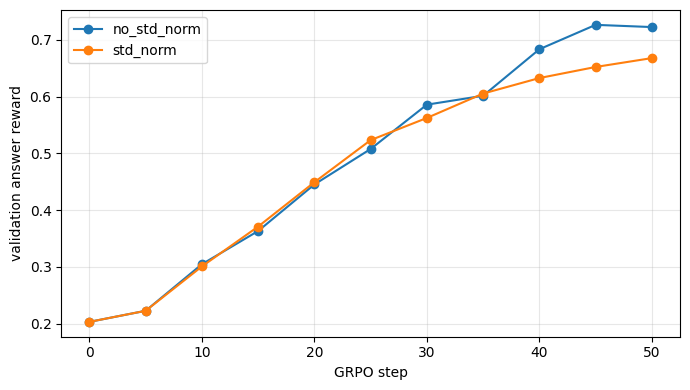

In [4]:
import json, zipfile
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

root = Path("/content/hw2/artifacts_3_5")
rows = []
for run in ["std_norm", "no_std_norm"]:
    hist = json.loads((root / run / "history.json").read_text())
    for row in hist:
        row = dict(row)
        row["run"] = run
        rows.append(row)

df = pd.DataFrame(rows)
val = df[df["phase"] == "validation"]

plt.figure(figsize=(7, 4))
for run, g in val.groupby("run"):
    plt.plot(g["step"], g["answer_reward"], marker="o", label=run)
plt.xlabel("GRPO step")
plt.ylabel("validation answer reward")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(root / "validation_answer_reward.png", dpi=200)

with zipfile.ZipFile("/content/hw2_3_5_results.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for p in root.rglob("*"):
        if p.is_file():
            z.write(p, p.relative_to(root.parent))

files.download("/content/hw2_3_5_results.zip")
